## Task 2: Design clustering models using K-Means clustering for pattern discovery and data grouping
*Suggested Dataset: Iris Dataset*


### Subtask 2.1: Determining Clusters via the Elbow Method (WCSS)
**Concept:** Implement K-Means over cluster sizes ($k$) from 1 to 10 and plot the Within-Cluster Sum of Squares (WCSS) curve to find the optimal elbow point.


In [1]:
#code related to task 1
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Iris dataset
iris = load_iris()

# Extract features and target
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# Create DataFrame
iris_df = pd.DataFrame(
    X,
    columns=feature_names
)

iris_df["species_id"] = y
iris_df["species_name"] = [
    target_names[i] for i in y
]

# Standardize feature space
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Iris dataset loaded successfully.")
print("Standardized dataset dimensions:", X_scaled.shape)

print("\nFirst 5 rows:")
print(iris_df.head())

Iris dataset loaded successfully.
Standardized dataset dimensions: (150, 4)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  
3           0       setosa  
4           0       setosa  


In [2]:
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [4]:
from sklearn.cluster import KMeans

In [5]:
import matplotlib.pyplot as plt

In [6]:
wcss = []

In [7]:
k_range = range(1, 11)

In [8]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

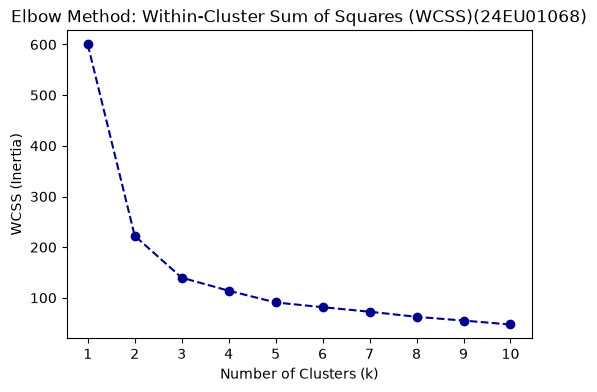

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS)(24EU01068)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()


### Subtask 2.2: Validating Optimal Clusters with Silhouette Analysis
**Concept:** Calculate and plot average silhouette scores across cluster counts ($k=2, 3, 4, 5$) to mathematically confirm the optimal number of groups.


In [10]:
from sklearn.metrics import silhouette_score

In [11]:
silhouette_scores = []

In [12]:
k_eval = range(2, 6)

In [13]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

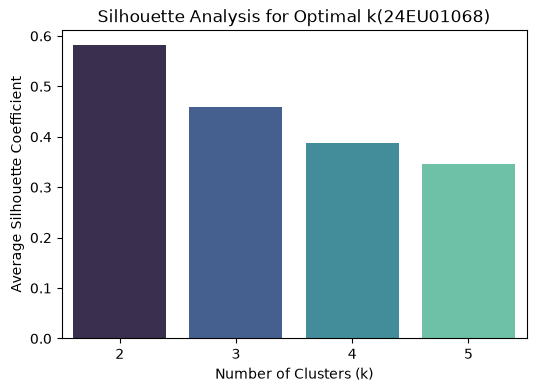

In [28]:
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("Silhouette Analysis for Optimal k(24EU01068)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()

In [15]:
best_k = k_eval[np.argmax(silhouette_scores)]

In [16]:
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


### Subtask 2.3: Implementing K-Means Clustering on the Raw Feature Space
**Concept:** Fit a K-Means model with $k=3$ on the raw standardized features, and assign cluster labels to each sample.


In [17]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [18]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

In [19]:
iris_df['cluster_raw'] = kmeans_raw_labels

In [20]:
print("K-Means clustering complete. First 5 sample allocations:")
print(iris_df[['species_name', 'cluster_raw']].head(5))

K-Means clustering complete. First 5 sample allocations:
  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


### Subtask 2.4: Extracting and Inspecting Cluster Centroids
**Concept:** Extract coordinates of the calculated centroids and inverse-scale them back to the original units (cm) for standard physical interpretation.


In [21]:
raw_centroids_scaled = kmeans_raw.cluster_centers_

In [22]:
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [23]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=feature_names)

In [24]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")
print(centroids_df)

--- Estimated Cluster Centroids (Original Physical Units - cm) ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.801887          2.673585           4.369811          1.413208
1           5.006000          3.428000           1.462000          0.246000
2           6.780851          3.095745           5.510638          1.972340


### Subtask 2.5: Visualizing Raw Clusters and Centroids
**Concept:** Create a scatter plot comparing Petal Length vs. Petal Width, coloring points by cluster assignment and plotting the centroids.


In [25]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [26]:
raw_data = scaler.inverse_transform(X_scaled)

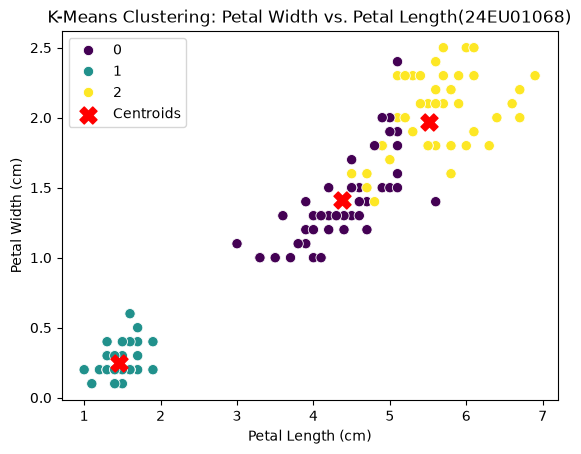

In [27]:
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')
plt.scatter(
    raw_centroids_physical[:, 2], 
    raw_centroids_physical[:, 3], 
    color='red', 
    marker='X', 
    s=150, 
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length(24EU01068)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()